# DSC 80 - Discussion 04

# Combining DataFrames, Permutation Testing & Data Visualization


In [2]:
# for formatting purposes
def multi_table(table_list):
    ''' Acceps a list of IpyTable objects and returns a table which contains each IpyTable in a cell
    '''
    return HTML(
        '<table><tr style="background-color:white;">' + 
        ''.join(['<td>' + table._repr_html_() + '</td>' for table in table_list]) +
        '</tr></table>'
    )

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import HTML

%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")

# 1. Review: Combining DataFrames 

#### `merge()`

* Used to combine two (or more) dataframes on the basis of **values of common columns** (indices can also be used, use `left_index=True` and/or `right_index=True`).
    * If we are joining columns on columns, the DataFrame indexes will be ignored. 
    * If we are joining indexes on indexes or indexes on a column or columns, the index will be passed on.

* **`on`**: column or index level names to join on. 
    * These must be found in both DataFrames. 
    * If `on` is `None` and not merging on indexes then this defaults to the intersection of the columns in both DataFrames.

* **`how`**: specifies how to determine which keys are to be included in the resulting table. 
    * If a key (column name) combination does not appear in either the left or the right tables, the values in the joined table will be `np.NaN`.
    * Defaults to `inner`, joining will be performed on index. 

#### `concat()`

* Used to append one (or more) dataframes one below the other (or sideways, depending on whether the axis option is set to 0 or 1).
    * Useful if we have two or more data sets containing the same columns but different rows of data.
    * We can also the columns from one `Dataframe` to those of another `Dataframe`.

#### `join()`

* Used to merge two dataframes on the basis of the index; instead of using `merge()` with the option `left_index=True` we can use `join()`.
    * Join operation honors the object on which it is called: `a.join(b)` $ \neq $ `b.join(a)`.

<img src="imgs/join_types.jpg">

1. **Inner Join** – default behavior, only keep rows where the merge “on” value exists in both the left and right dataframes.
2. **Left Outer** – keep every row in the left dataframe.
    * Where there are missing values of the “on” variable in the right dataframe, add `np.NaN` values in the result.
3. **Right Join** – keep every row in the right dataframe. 
    * Where there are missing values of the “on” variable in the left column, add `np.NaN` values in the result.
4. **Outer Join** – returns all the rows from the left dataframe, all the rows from the right dataframe, and matches up rows where possible, with `NaNs` elsewhere.

We'll start with a simple example:

In [5]:
left = pd.DataFrame({'key': ['foo', 'bar'], 'val': [1, 2]}).set_index('key')
right = pd.DataFrame({'key': ['foo', 'bar'], 'val': [4, 5]}).set_index('key')

joined = left.join(right, lsuffix='_l', rsuffix='_r')

multi_table([left, right, joined])

Now let's try something a bit more complex:

In [6]:
df1_data = {
    'Year' : [2014, 2014, 2014, 2014, 2014],
    'Week' : ['A', 'B', 'B', 'C', 'D'],
    'Color' : ['Red', 'Red', 'Black', 'Red', 'Green'],
    'Val' : [50, 60, 70, 10, 20]
}

df1 = pd.DataFrame(df1_data).set_index('Week')

df2_data = {
    'Year' : [2014, 2014, 2014, 2014, 2014],
    'Week' : ['A', 'B', 'C', 'C', 'D'],
    'Color' : ['Black', 'Black', 'Green', 'Red', 'Red'],
    'Score' : [30, 100, 50, 20, 40]
}

df2 = pd.DataFrame(df2_data).set_index('Week')

multi_table([df1, df2])

,Year,Color,Val
Week,,,
A,2014,Red,50
B,2014,Red,60
B,2014,Black,70
C,2014,Red,10
D,2014,Green,20
,Year,Color,Score
Week,,,
A,2014,Black,30
B,2014,Black,100


In [7]:
# how many rows, how many columns?
df1.join(df2, lsuffix='_l', rsuffix = '_r')

,Year_l,Color_l,Val,Year_r,Color_r,Score
Week,,,,,,
A,2014,Red,50,2014,Black,30
B,2014,Red,60,2014,Black,100
B,2014,Black,70,2014,Black,100
C,2014,Red,10,2014,Green,50
C,2014,Red,10,2014,Red,20
D,2014,Green,20,2014,Red,40


In [8]:
# will this be any different?
df2.join(df1, lsuffix='_l', rsuffix = '_r')

,Year_l,Color_l,Score,Year_r,Color_r,Val
Week,,,,,,
A,2014,Black,30,2014,Red,50
B,2014,Black,100,2014,Red,60
B,2014,Black,100,2014,Black,70
C,2014,Green,50,2014,Red,10
C,2014,Red,20,2014,Red,10
D,2014,Red,40,2014,Green,20


In [12]:
def check_merge_cardinality(left, right, result, name="Join"):
    """ 
    If len(result) > len(left) in a Left Join, you have duplicate keys.
    """
    print(f"Left Rows: {len(left)} | Right Rows: {len(right)} | Result: {len(result)}")
    if len(result) > len(left):
        print("⚠️ Check for non-unique join keys.")
    else:
        print("✅ Cardinality preserved.")

df_joined = df1.join(df2, lsuffix='_l', rsuffix='_r')
check_merge_cardinality(df1, df2, df_joined)

Left Rows: 5 | Right Rows: 5 | Result: 6
⚠️ Check for non-unique join keys.


# 2. Review: Permutation Testing

### Hypothesis testing

- In "vanilla" hypothesis testing, we are given a **single** observed sample, and are asked to make an assumption as to how it came to be.
    - This assumption is the **null hypothesis**.
    - This assumption must be a **probability model**, since we use it to generate new data.
- We simulate data under the null hypothesis to answer the question, **if this assumption is true, how likely is the given observation?**

### Permutation testing

* **Given two observed samples, are they fundamentally different, or could they have been generated by the same process?**
* In a permutation test, we decide whether two **fixed** random samples come from the same distribution.
- Unlike in the previous hypothesis testing examples, when conducting a permutation test, you do not know **what distribution** generated your two samples!


## Revisit: Birth weight example 👶

### Birth weight and Maternal Age

- Is there a significant difference in the weights of babies born to mothers who belong to certain categories?
- We have 3 groups:
    - Babies whose mothers belonged to age group 15-25
    - Babies whose mothers belonged to age group 25-35
    - Babies whose mothers belonged to age group 35-45
- In each group, the relevant attribute is the birth weight of the baby. 

In [13]:
# Kaiser dataset, 70s 
import os
baby_fp = os.path.join('data', 'baby1.csv')
baby = pd.read_csv(baby_fp)
baby.head()
# baby['Maternal Age'].max()

,Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
0,120,284,27,62,100,False
1,113,282,33,64,135,False
2,128,279,28,64,115,True
3,108,282,23,67,125,True
4,136,286,25,62,93,False


In [14]:
mother_age_and_birthweight = baby[['Maternal Age', 'Birth Weight']]
mother_age_and_birthweight.head()

,Maternal Age,Birth Weight
0,27,120
1,33,113
2,28,128
3,23,108
4,25,136


### Exploratory data analysis

How many babies are in each group?

In [15]:
# Data binning
bins = [15,25,35,45]
group_names = ['15-25','25-35','35-45']
mother_age_and_birthweight['Age Bracket'] = pd.cut(mother_age_and_birthweight['Maternal Age'],bins,labels=group_names)
mother_age_and_birthweight.head()

/var/folders/zf/94x0k5092zgfxzfr4p5680gc0000gn/T/ipykernel_40441/4268142971.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mother_age_and_birthweight['Age Bracket'] = pd.cut(mother_age_and_birthweight['Maternal Age'],bins,labels=group_names)


,Maternal Age,Birth Weight,Age Bracket
0,27,120,25-35
1,33,113,25-35
2,28,128,25-35
3,23,108,15-25
4,25,136,15-25


What is the average birth weight within each group?

In [16]:
mother_age_and_birthweight.groupby('Age Bracket')[['Birth Weight']].mean()

/var/folders/zf/94x0k5092zgfxzfr4p5680gc0000gn/T/ipykernel_40441/351619242.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mother_age_and_birthweight.groupby('Age Bracket')[['Birth Weight']].mean()


,Birth Weight
Age Bracket,
15-25,118.503861
25-35,120.354839
35-45,119.710938


Note that 16 ounces are in 1 pound, so the above weights are ~7-8 pounds.

### Visualizing birth weight distributions

- Below, we draw the distribution of birth weights, separated by mother's Age group.
- The histograms appear to be different, but is the difference possible **due to random chance** or is there a significant difference in the two distributions?

/var/folders/zf/94x0k5092zgfxzfr4p5680gc0000gn/T/ipykernel_40441/3102862854.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Age Bracket')['Birth Weight']


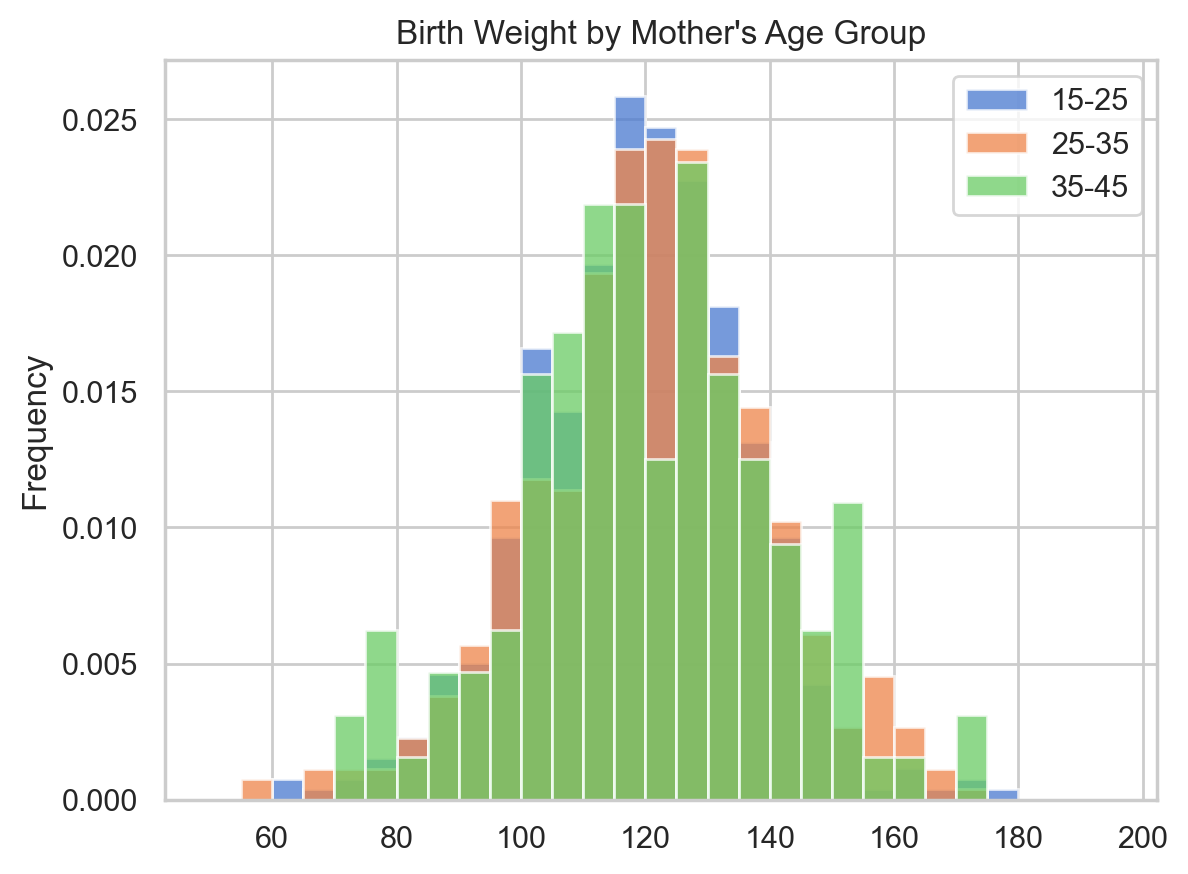

In [17]:
title = "Birth Weight by Mother's Age Group"

(
    mother_age_and_birthweight
    .groupby('Age Bracket')['Birth Weight']
    .plot(kind='hist', density=True, legend=True,
          ec='w', bins=np.arange(50, 200, 5), alpha=0.75,
          title=title)
);    

/var/folders/zf/94x0k5092zgfxzfr4p5680gc0000gn/T/ipykernel_40441/2443704854.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Age Bracket')['Birth Weight']


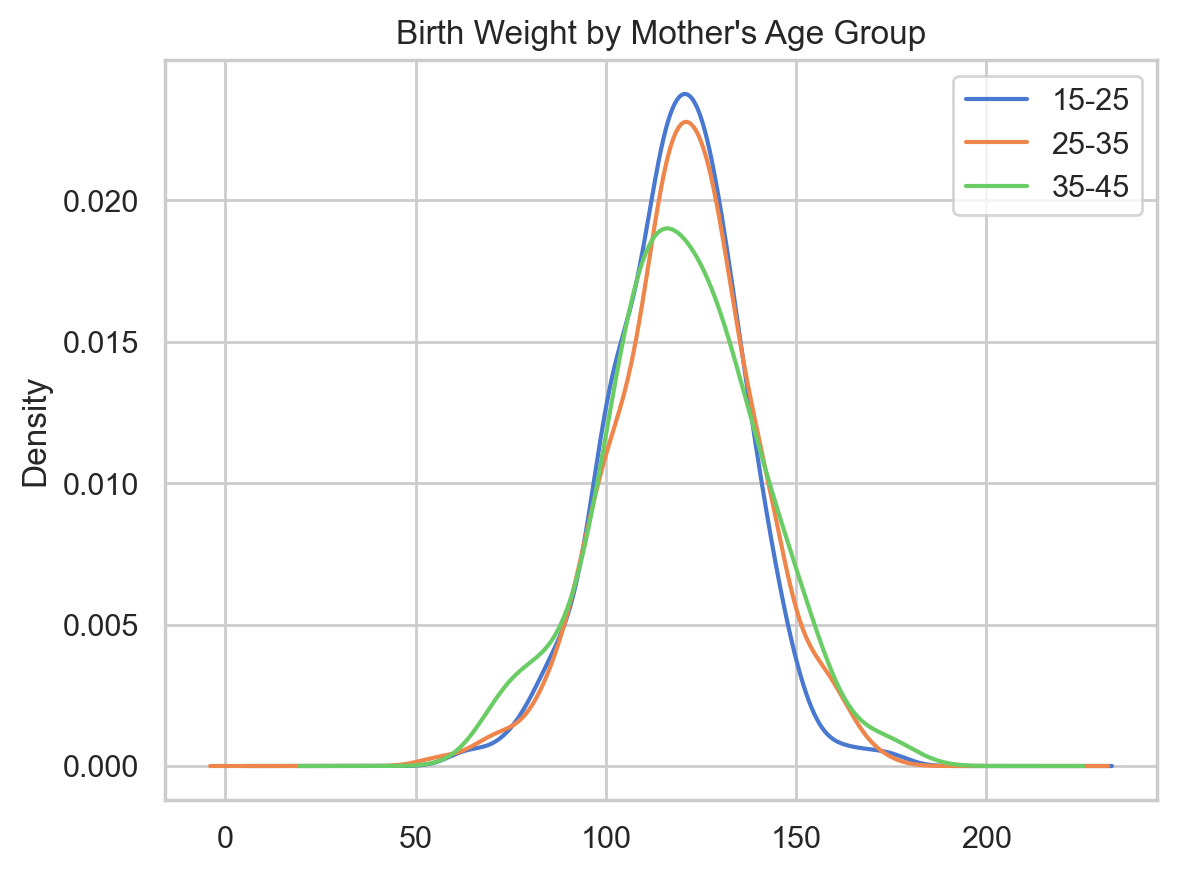

In [18]:
(
    mother_age_and_birthweight
    .groupby('Age Bracket')['Birth Weight']
    .plot(kind='kde', legend=True,
          title=title)
);    

In [32]:
from matplotlib import pyplot as plt
shuffled_weights = (
    mother_age_and_birthweight['Birth Weight']
    .sample(frac=1)
    .reset_index(drop=True) # Question: What will happen if we do not reset the index? #(df['Birth Weight'] == df['Shuffled Birth Weight']).all()
)

original_and_shuffled = (
    mother_age_and_birthweight
    .assign(**{'Shuffled Birth Weight': shuffled_weights})
)


original_and_shuffled.head(10)


,Maternal Age,Birth Weight,Age Bracket,Shuffled Birth Weight
0,27,120,25-35,99
1,33,113,25-35,99
2,28,128,25-35,123
3,23,108,15-25,112
4,25,136,15-25,129
5,33,138,25-35,110
6,23,132,15-25,98
7,25,120,15-25,117
8,30,143,25-35,135
9,27,140,25-35,97


In [33]:
observed_difference = (
    mother_age_and_birthweight
    .groupby('Age Bracket')['Birth Weight']
    .mean()
    .diff()
    .iloc[-1]
)

observed_difference

/var/folders/zf/94x0k5092zgfxzfr4p5680gc0000gn/T/ipykernel_40441/3825631727.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Age Bracket')['Birth Weight']


np.float64(-0.6439012096774235)

/var/folders/zf/94x0k5092zgfxzfr4p5680gc0000gn/T/ipykernel_40441/863780864.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  original_and_shuffled.groupby('Age Bracket')['Shuffled Birth Weight'].plot(kind='kde', ax=axes[0])
/var/folders/zf/94x0k5092zgfxzfr4p5680gc0000gn/T/ipykernel_40441/863780864.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  original_and_shuffled.groupby('Age Bracket')['Birth Weight'].plot(kind='kde', ax=axes[1])


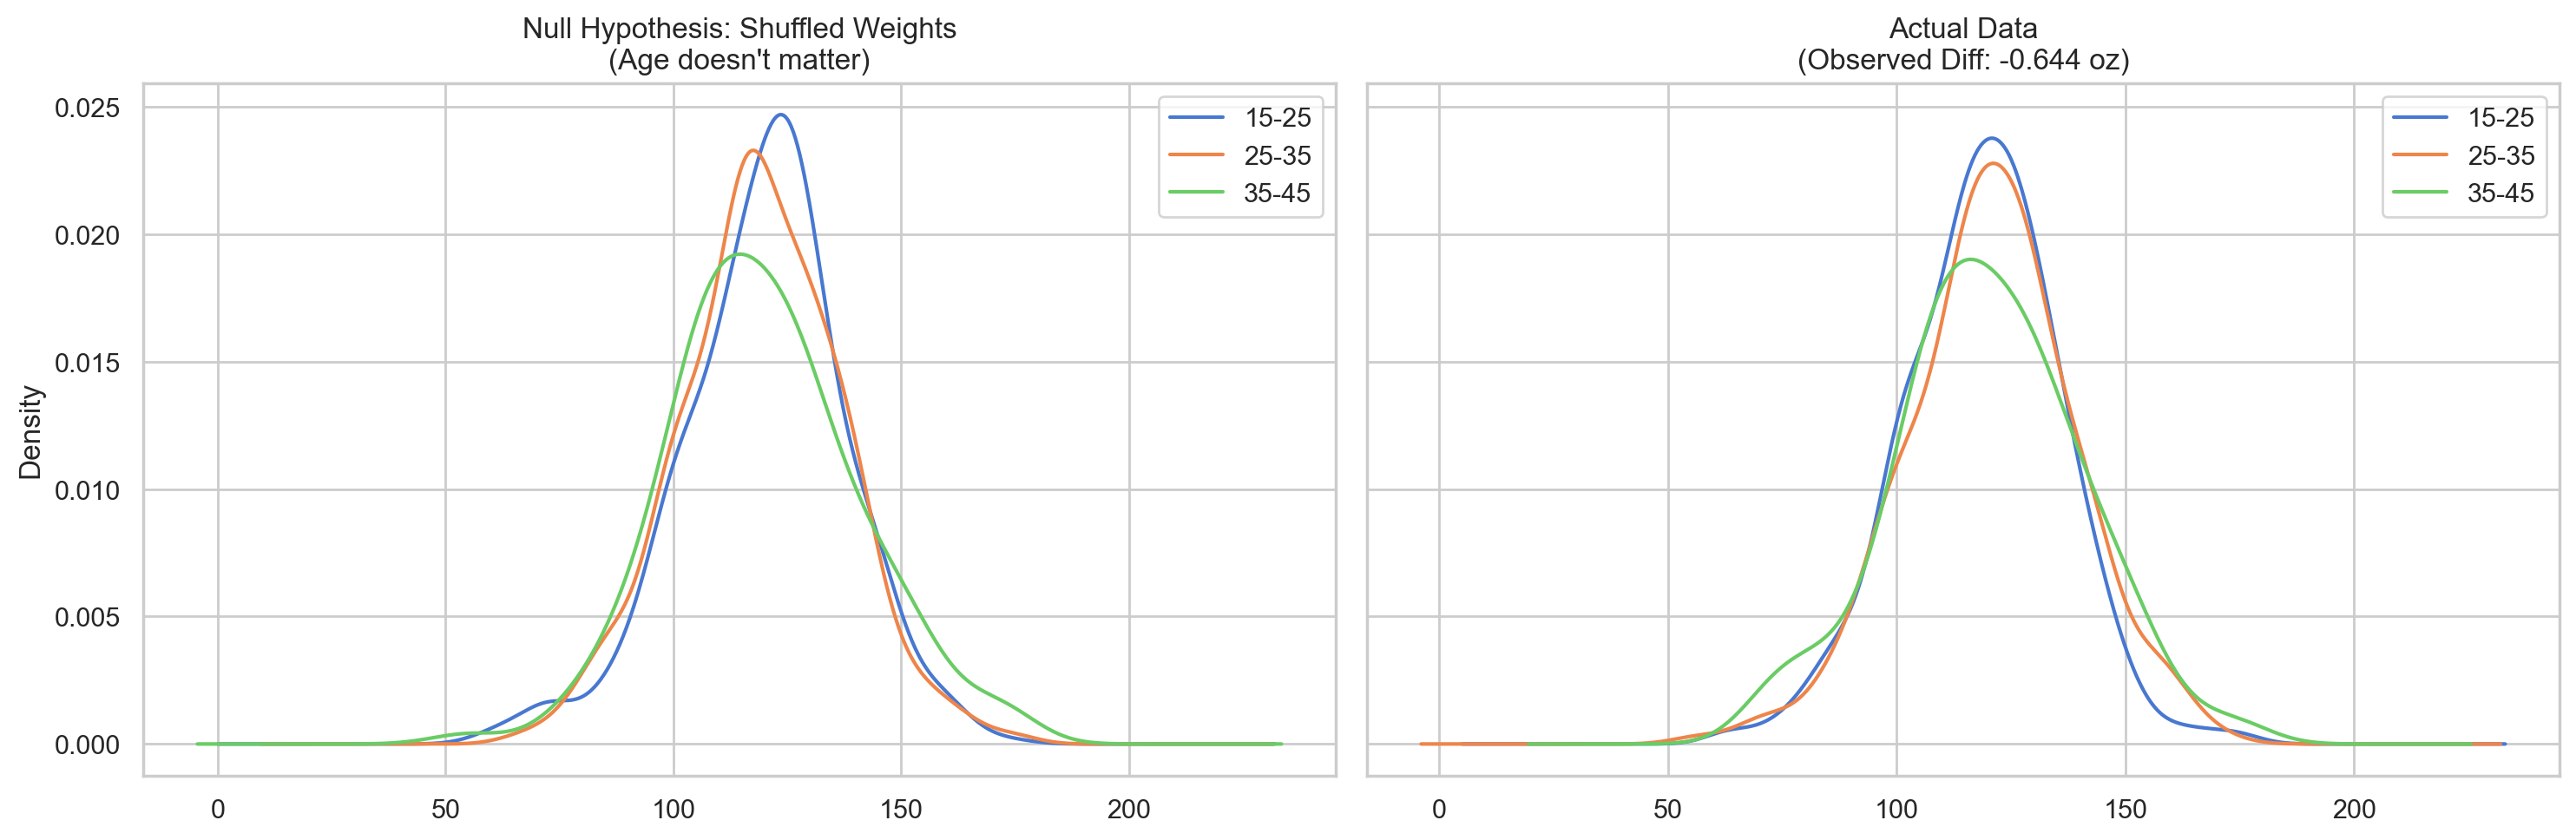

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Plot 1: The Null (Shuffled)
original_and_shuffled.groupby('Age Bracket')['Shuffled Birth Weight'].plot(kind='kde', ax=axes[0])
axes[0].set_title('Null Hypothesis: Shuffled Weights\n(Age doesn\'t matter)')
axes[0].legend()

# Plot 2: The Reality (Observed)
original_and_shuffled.groupby('Age Bracket')['Birth Weight'].plot(kind='kde', ax=axes[1])
axes[1].set_title(f'Actual Data\n(Observed Diff: {observed_difference:.3f} oz)')
axes[1].legend()

plt.tight_layout()

*Conclusion* We don't "Accept" the Null Hypothesis. We simply "Fail to Reject" it. We are saying, "Based on these 1,200 babies, we can't tell the difference between these two groups and random noise."

# 3. Plotting in `pandas`

## is as easy as `.plot()`

* `Series.plot()` plots a column.

In [22]:
data = pd.read_csv('data/data1.csv')

In [23]:
data.head()

,id,x,z0,z1,z2,z3
0,3,0.0000,0.000000,0.000000,-0.000000,0.273816
1,3,0.1001,-0.102628,0.001595,0.052832,-0.487302
2,3,0.2002,-0.223206,0.006378,-0.198124,-0.844929
3,2,0.3003,-0.484955,0.014347,0.126451,-0.357906
4,2,0.4004,0.350514,0.025499,0.439444,0.602113


In [24]:
# select a column from data
z0 = data['z0']
z0.head()

0    0.000000
1   -0.102628
2   -0.223206
3   -0.484955
4    0.350514
Name: z0, dtype: float64

* Use a line plot to plot numeric data.
* `data.plot()` plots a line plot by default.
    - The x-axis is the index by default
    - Can be called out using the key-word argument `x`.

<Axes: >

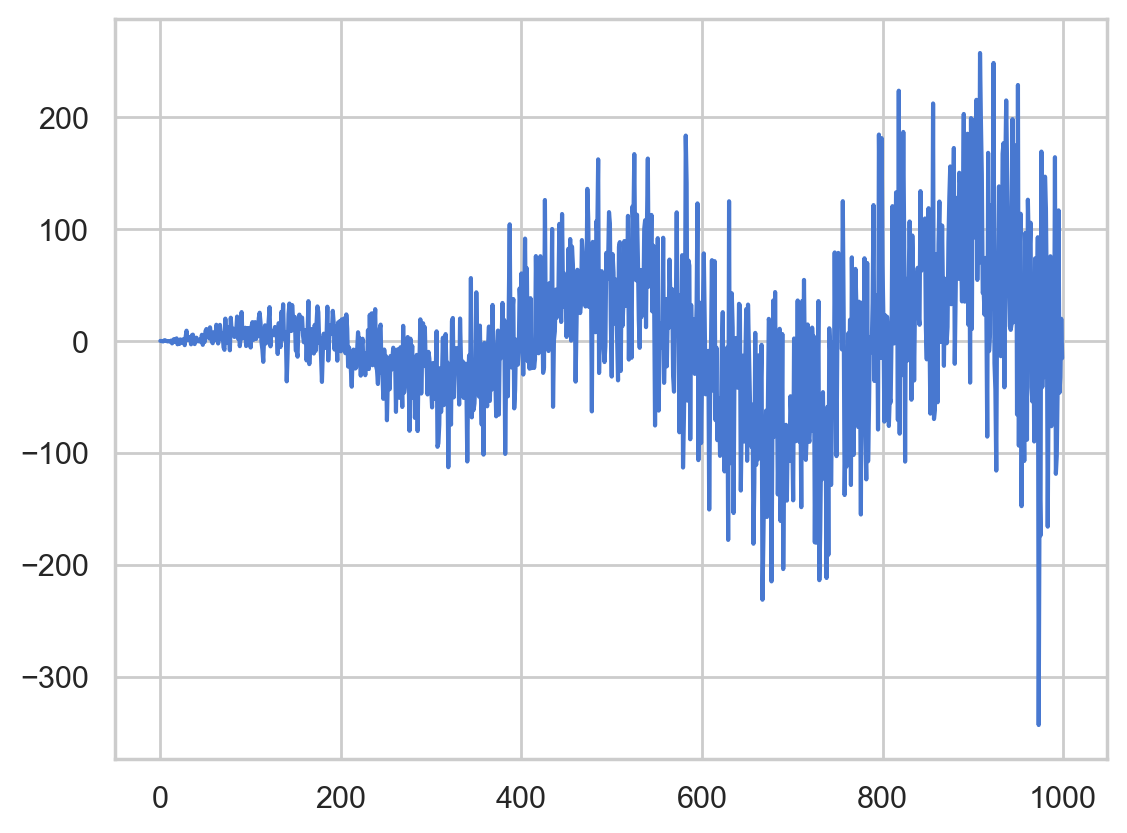

In [25]:
# index is [0...1000]
z0.plot()

In [26]:
# set index to plot correct x-axis
z0 = data.set_index('x').loc[:, 'z0']
z0.head()

x
0.0000    0.000000
0.1001   -0.102628
0.2002   -0.223206
0.3003   -0.484955
0.4004    0.350514
Name: z0, dtype: float64

<Axes: xlabel='x'>

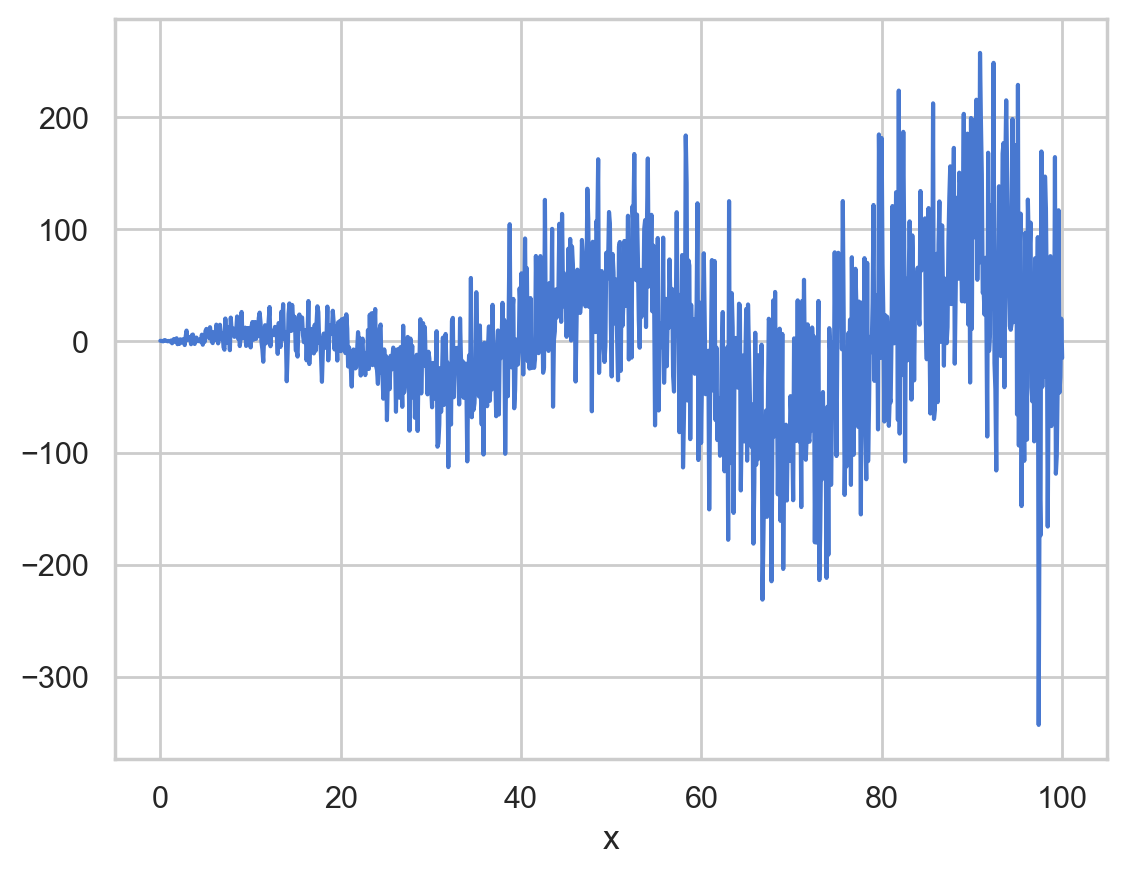

In [27]:
z0.plot()

<Axes: xlabel='x'>

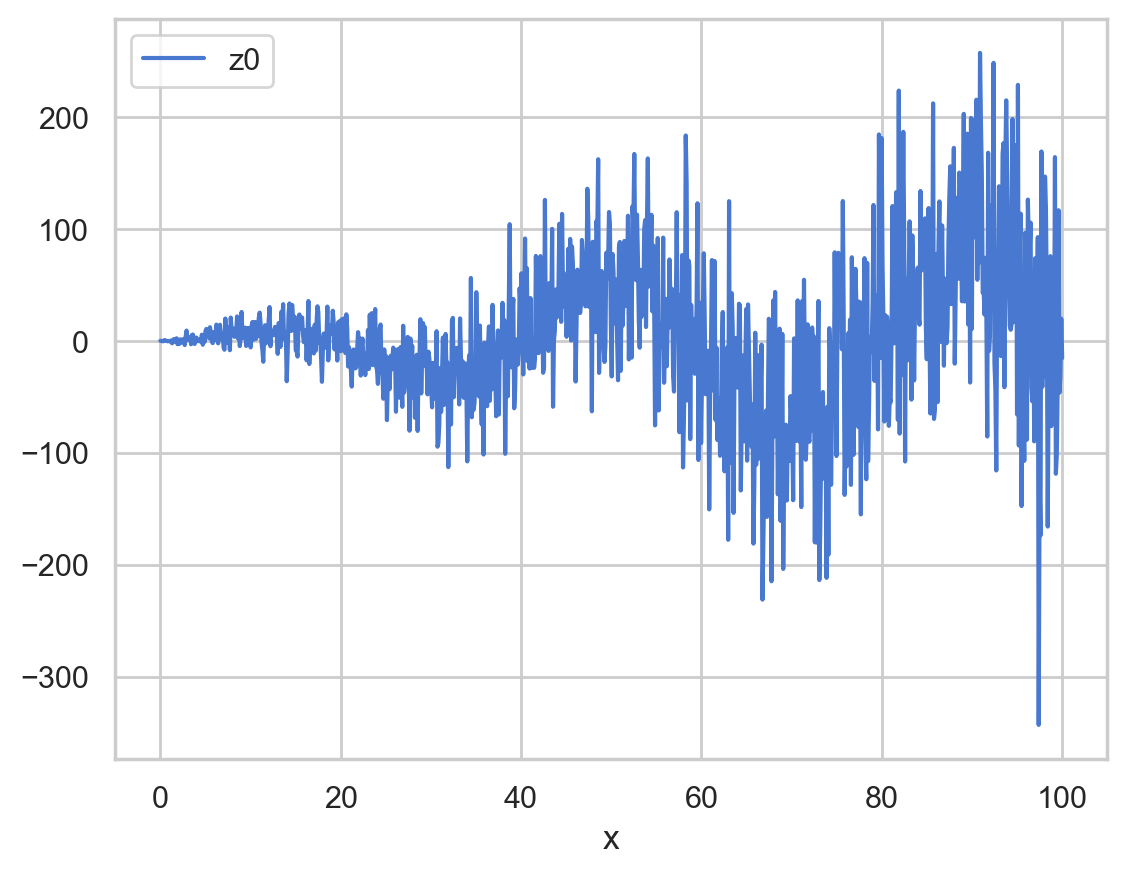

In [28]:
# set x-axis using a keyword argument
data.plot(x='x', y='z0')

### Plotting (quantitative) empirical distributions in Pandas

* Use the key-word argument `kind`
```
kind : str
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    ...
```
* The `hist` keyword by default uses 10 bins, and returns the *count* of observations within those bins.
    - use `density=True` to return a histogram whose area is normalized to 1.

<Axes: ylabel='Frequency'>

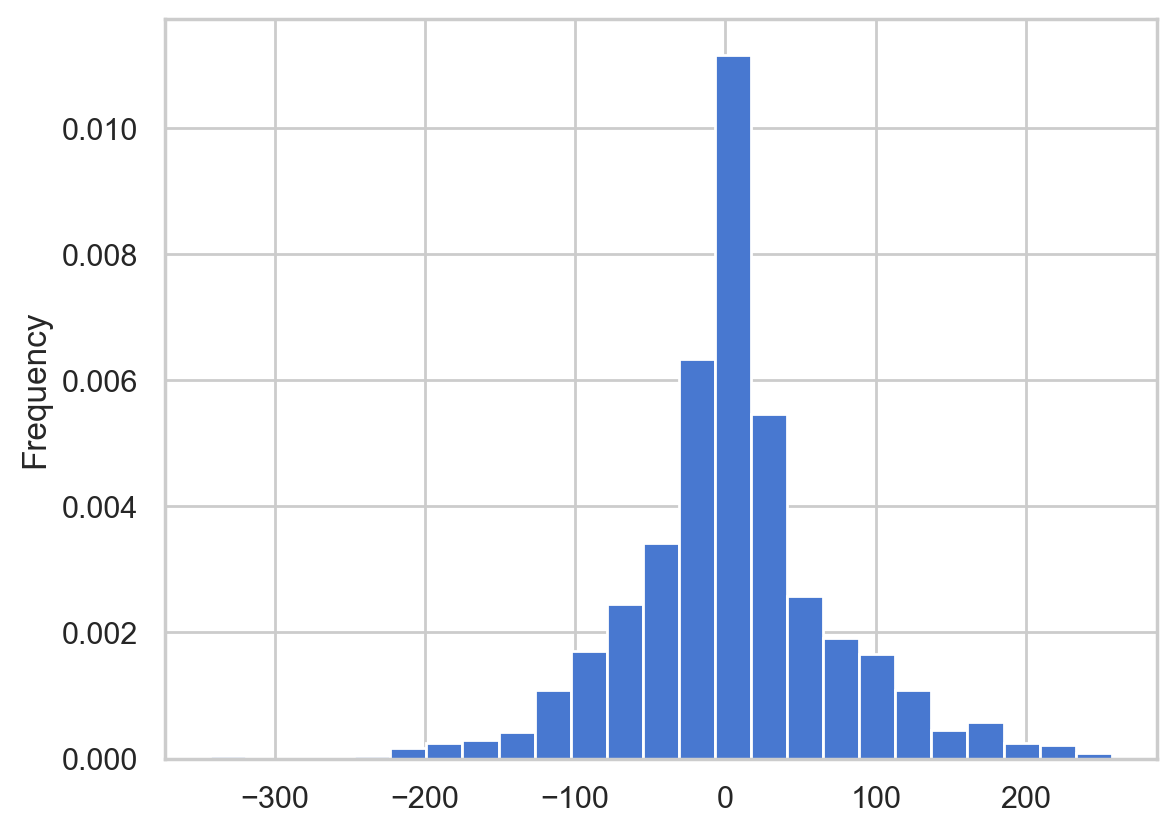

In [29]:
# histogram of z0 values; 
# 25 bins.
# density = normalized histogram

z0.plot(kind='hist', bins=25, density=True, ec='w')

<Axes: ylabel='Density'>

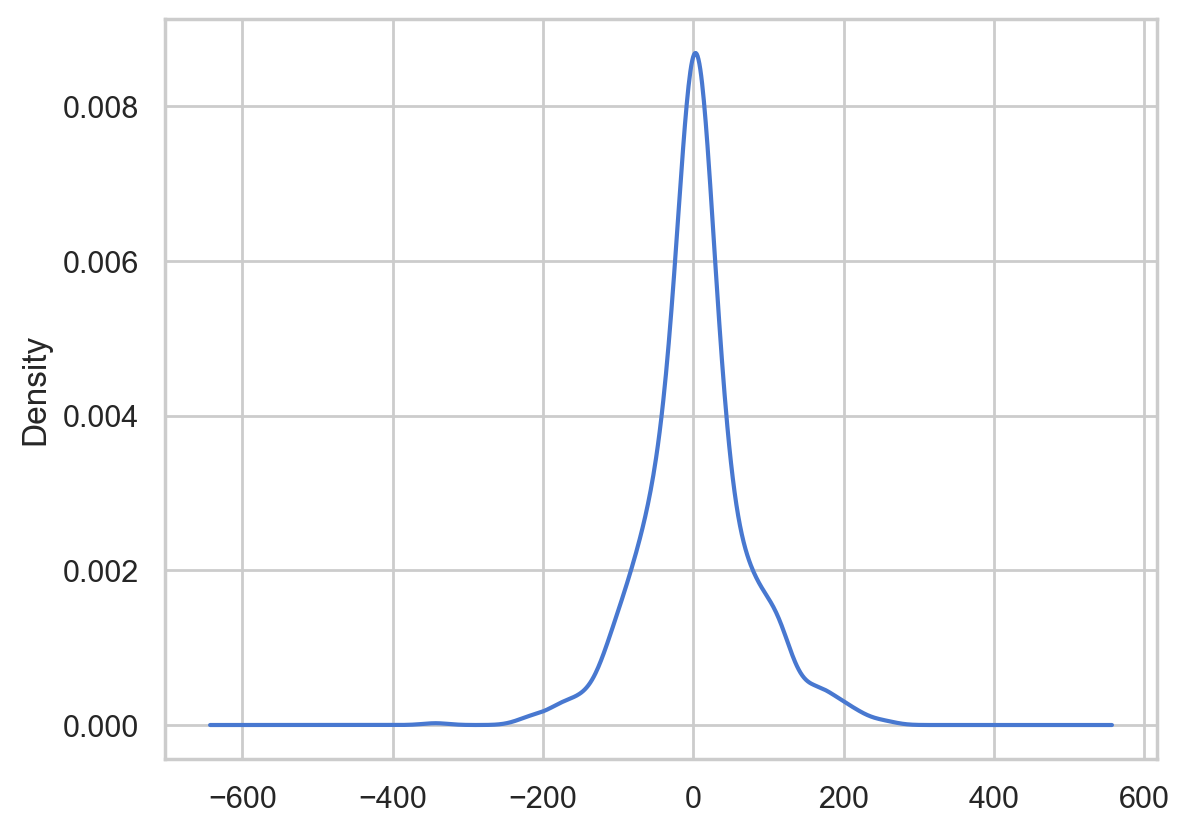

In [30]:
# kernel density estimate of the distribution
# smooth approximation of the empirical distribution

z0.plot(kind='kde')

<Axes: >

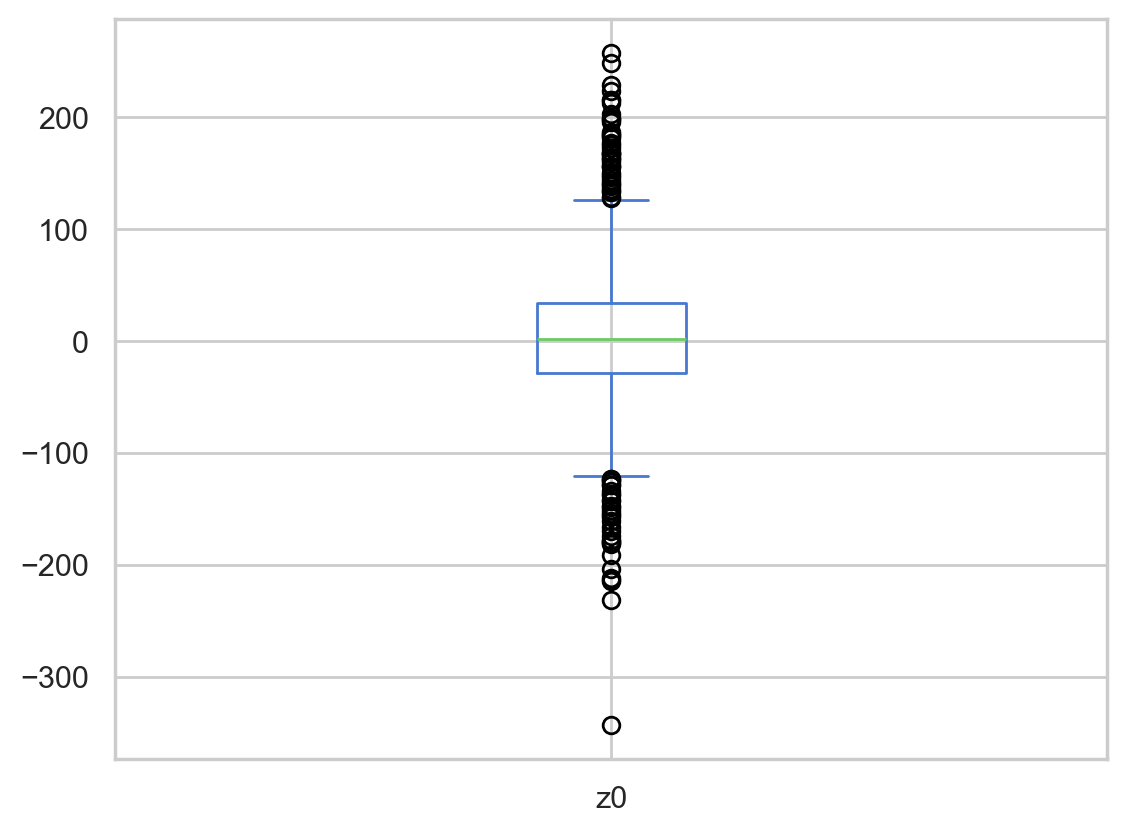

In [31]:
z0.plot(kind='box')